# 🚕 Q-Learning en Taxi-v4 — Trabajo en casa

En este ejercicio aplicará Q-Learning al ambiente **Taxi-v4** de Gymnasium.

La lógica es la misma trabajada en FrozenLake:

$$
(s_t,a_t) \rightarrow (r_{t+1},s_{t+1})
$$

y la actualización:

$$
Q(s_t,a_t)
\leftarrow
Q(s_t,a_t)
+
\alpha
\left[
r_{t+1}
+
\gamma \max_a Q(s_{t+1},a)
-
Q(s_t,a_t)
\right]
$$

## Objetivo

Implementar y analizar un agente Q-Learning capaz de aprender a recoger un pasajero y llevarlo a su destino.


## 1. Preparación

Instale Gymnasium si es necesario:

```bash
pip install gymnasium[toy-text]
```


In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

from IPython.display import HTML
from matplotlib import animation


In [2]:
# Semillas para que los resultados sean reproducibles
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Crear el ambiente

Taxi tiene un número de estados mucho mayor que FrozenLake.

Cada estado codifica:

- posición del taxi,
- ubicación del pasajero,
- destino del pasajero.

Las acciones posibles son:

| Acción | Significado |
|---|---|
| 0 | South |
| 1 | North |
| 2 | East |
| 3 | West |
| 4 | Pickup |
| 5 | Dropoff |


In [3]:
env = gym.make("Taxi-v4", render_mode="rgb_array")
env.action_space.seed(SEED)

print("Número de estados:", env.observation_space.n)
print("Número de acciones:", env.action_space.n)


Número de estados: 500
Número de acciones: 6


### Pregunta 1

¿Cuántos estados y cuántas acciones tiene Taxi-v4?

Explique brevemente por qué Taxi tiene muchos más estados que FrozenLake.


**Respuesta:**

Taxi tiene **500 estados** y **6 acciones**.

La razón es que el estado no es solo la posición del agente, sino una combinación de varias variables:

$$|\mathcal{S}| = \underbrace{25}_{\text{posiciones del taxi (5×5)}} \times \underbrace{5}_{\text{ubicación del pasajero (R, G, Y, B o dentro del taxi)}} \times \underbrace{4}_{\text{destinos}} = 500$$

En FrozenLake 4x4 el estado es únicamente la casilla donde está el agente, por eso solo hay 16 estados. En Taxi la misma casilla corresponde a 20 estados distintos, porque la decisión correcta depende también de dónde está el pasajero y a dónde va. El número de estados crece de forma multiplicativa con cada variable que se agrega a la descripción del mundo.

## 3. Observar una interacción

Ejecute una acción aleatoria y observe qué devuelve el ambiente.


In [4]:
state, info = env.reset(seed=42)

action = env.action_space.sample()

next_state, reward, terminated, truncated, info = env.step(action)

print("Estado:", state)
print("Acción:", action)
print("Nuevo estado:", next_state)
print("Recompensa:", reward)
print("Terminated:", terminated)


Estado: 386
Acción: 0
Nuevo estado: 486
Recompensa: -1
Terminated: False


### Pregunta 2

En la interacción anterior identifique:

$$
s_t,\quad a_t,\quad r_{t+1},\quad s_{t+1}
$$

¿Qué representa cada elemento?


**Respuesta:**

Con `seed=42` se obtuvo:

$$s_t = 386,\quad a_t = 0\ (\text{South}),\quad r_{t+1} = -1,\quad s_{t+1} = 486$$

1. $s_t$ es el estado actual, un entero que codifica en un solo número la posición del taxi, la ubicación del pasajero y el destino.
2. $a_t$ es la acción que tomó el agente en ese estado; aquí fue escogida al azar con `env.action_space.sample()`.
3. $r_{t+1}$ es la recompensa que devuelve el ambiente por esa transición. Taxi da $-1$ por cada paso (para incentivar rutas cortas), $-10$ por un pickup o dropoff ilegal y $+20$ por entregar al pasajero en su destino.
4. $s_{t+1}$ es el nuevo estado. Pasó de 386 a 486: el taxi bajó una fila y el código aumentó en 100, lo que coincide con la codificación `((fila*5 + col)*5 + pasajero)*4 + destino`.

`terminated=False` indica que el episodio continúa, porque el pasajero todavía no ha sido entregado.

## 4. Inicializar la Q-table

Cada fila corresponde a un estado y cada columna a una acción.

Inicialmente:

$$
Q(s,a)=0
$$


In [5]:
n_states = env.observation_space.n
n_actions = env.action_space.n

Q = np.zeros((n_states, n_actions))

print("Shape de Q:", Q.shape)
Q[:5]


Shape de Q: (500, 6)


array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

### Pregunta 3

¿Cuántos valores debe aprender el agente en total?

Calcule:

$$
|\mathcal{S}| \times |\mathcal{A}|
$$


**Respuesta:**

$$|\mathcal{S}| \times |\mathcal{A}| = 500 \times 6 = 3000$$

El agente debe estimar 3000 valores $Q(s,a)$, frente a $16 \times 4 = 64$ en FrozenLake. En la práctica algunos estados casi nunca se visitan (por ejemplo, combinaciones donde el pasajero ya está en su destino al inicio no se generan), así que no todas las celdas reciben la misma cantidad de actualizaciones.

## 5. Política $\epsilon$-greedy

Implemente una función que:

- con probabilidad $\epsilon$ seleccione una acción aleatoria;
- en otro caso seleccione:

$$
\arg\max_a Q(s,a)
$$

### Actividad 1
Complete la función.


In [6]:
def choose_action(Q, state, epsilon, env):
    # 1. Explorar con probabilidad epsilon
    if random.random() < epsilon:
        return int(env.action_space.sample())

    # 2. Explotar: acción con mayor Q (desempate aleatorio entre las mejores)
    q_values = Q[state]
    best_actions = np.flatnonzero(q_values == np.max(q_values))
    return int(np.random.choice(best_actions))


## 6. Actualización de Q

La regla de actualización es:

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
\left[
r+
\gamma\max_{a'}Q(s',a')
-
Q(s,a)
\right]
$$

### Actividad 2
Complete la función.


In [7]:
def update_q(Q, state, action, reward, next_state, alpha, gamma, done=False):
    # Si el episodio terminó, no hay valor futuro que sumar
    best_next_q = 0.0 if done else np.max(Q[next_state])

    # Target TD: r + gamma * max_a' Q(s', a')
    td_target = reward + gamma * best_next_q

    # Error TD: diferencia entre el target y la estimación actual
    td_error = td_target - Q[state, action]

    # Actualización
    Q[state, action] += alpha * td_error
    return td_error


## 7. Entrenamiento

Ahora implemente el ciclo completo de Q-Learning.

En cada episodio:

1. reiniciar el ambiente;
2. escoger una acción;
3. ejecutar `env.step(action)`;
4. actualizar $Q(s,a)$;
5. mover el agente a `next_state`;
6. terminar cuando el episodio finalice.

Use inicialmente:

```python
alpha = 0.1
gamma = 0.95
epsilon = 0.1
episodes = 5000
```

### Actividad 3
Complete la función.


In [8]:
def train_q_learning(
    env,
    Q,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    max_steps=200
):
    rewards = []

    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(max_steps):

            # 1: escoger acción con epsilon-greedy
            action = choose_action(Q, state, epsilon, env)

            # 2: ejecutar acción en el ambiente
            next_state, reward, terminated, truncated, _ = env.step(action)

            # 3: actualizar Q (solo terminated anula el valor futuro;
            #    truncated es un corte artificial por tiempo)
            update_q(Q, state, action, reward, next_state, alpha, gamma, done=terminated)

            # 4: actualizar estado y recompensa acumulada
            state = next_state
            total_reward += reward

            # 5: terminar si corresponde
            if terminated or truncated:
                break

        rewards.append(total_reward)

    return Q, rewards


## 8. Entrenar el agente

Ejecute el entrenamiento una vez haya completado las funciones anteriores.


In [9]:
Q_initial = np.zeros((n_states, n_actions))

Q_trained, rewards = train_q_learning(
    env,
    Q_initial.copy(),
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1
)


## 9. Curva de aprendizaje

Observe cómo cambia la recompensa durante el entrenamiento.


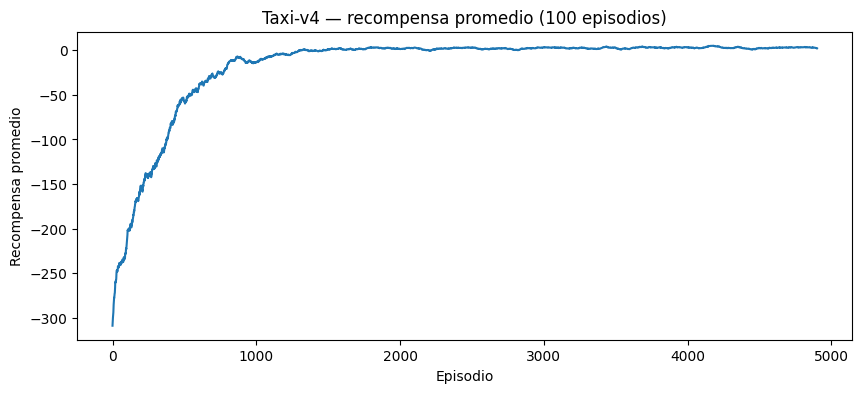

In [10]:
window = 100

moving_average = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 4))
plt.plot(moving_average)
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Taxi-v4 — recompensa promedio ({window} episodios)")
plt.show()


### Evaluación de la política greedy

Para saber qué tan buena es la política aprendida la evaluamos sin exploración ($\epsilon=0$) en 200 episodios nuevos.

In [11]:
def evaluate_policy(env, Q, n_episodes=200, max_steps=200):
    total_rewards, steps_list, successes = [], [], 0
    for _ in range(n_episodes):
        state, _ = env.reset()
        total, steps = 0, 0
        for steps in range(1, max_steps + 1):
            q_values = Q[state]
            action = int(np.random.choice(np.flatnonzero(q_values == q_values.max())))
            state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            if terminated:
                successes += 1
                break
            if truncated:
                break
        total_rewards.append(total)
        steps_list.append(steps)
    return np.mean(total_rewards), np.mean(steps_list), successes / n_episodes

mean_r, mean_steps, success = evaluate_policy(env, Q_trained)
print(f"Recompensa media (greedy): {mean_r:.2f}")
print(f"Pasos promedio por episodio: {mean_steps:.2f}")
print(f"Tasa de éxito: {success:.1%}")
print(f"Recompensa media últimos 500 episodios de entrenamiento: {np.mean(rewards[-500:]):.2f}")
print(f"Recompensa media primeros 100 episodios: {np.mean(rewards[:100]):.2f}")

Recompensa media (greedy): 8.00
Pasos promedio por episodio: 13.01
Tasa de éxito: 100.0%
Recompensa media últimos 500 episodios de entrenamiento: 2.65
Recompensa media primeros 100 episodios: -308.85


### Pregunta 4

Describa la curva de aprendizaje.

- ¿La recompensa promedio mejora?
- ¿Después de aproximadamente cuántos episodios comienza a estabilizarse?
- ¿El comportamiento observado indica convergencia perfecta o solamente una política razonablemente buena?


**Respuesta:**

1. **Sí mejora, y mucho.** En los primeros 100 episodios la recompensa promedio es de aproximadamente $-309$: el taxi deambula hasta agotar los 200 pasos y hace muchos pickups y dropoffs ilegales. Al final del entrenamiento la media de los últimos 500 episodios está alrededor de $+2.7$.
2. **Estabilización:** la curva sube muy rápido en los primeros cientos de episodios y luego más despacio. La media móvil cruza el cero cerca del episodio 1400 y a partir de unos 1300 a 1500 episodios queda prácticamente plana.
3. **Política razonablemente buena, no convergencia perfecta demostrada.** La curva de entrenamiento se estabiliza en torno a $+2.7$ y no en el máximo posible, porque durante el entrenamiento se sigue explorando con $\epsilon=0.1$ (uno de cada diez pasos es aleatorio y a veces cae en un pickup o dropoff ilegal). Además la recompensa depende del punto de partida, que es aleatorio, por eso la curva siempre tiene ruido. Al evaluar la política **greedy** (sin exploración) en 200 episodios obtuvimos recompensa media de 8.0, 13 pasos en promedio y 100 % de éxito, lo que indica que la política está muy cerca de la óptima. Aun así no podemos afirmar convergencia exacta de todos los $Q(s,a)$: con $\alpha$ y $\epsilon$ constantes y solo 5000 episodios, los valores de estados poco visitados siguen siendo aproximados.

## 10. Reproducir un episodio

La siguiente función ejecuta una política greedy usando la Q-table aprendida y guarda los frames del episodio.


In [12]:
def play_episode(env, Q, max_steps=200, seed=None):
    state, _ = env.reset(seed=seed)

    frames = [env.render()]
    total_reward = 0

    for _ in range(max_steps):

        q_values = Q[state]
        max_q = np.max(q_values)

        best_actions = np.flatnonzero(q_values == max_q)
        action = int(np.random.choice(best_actions))

        next_state, reward, terminated, truncated, _ = env.step(action)

        frames.append(env.render())

        total_reward += reward
        state = next_state

        if terminated or truncated:
            break

    return frames, total_reward


def frames_to_video(frames, interval=500):
    fig = plt.figure(figsize=(6, 4))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


## 11. Comparar antes y después

Primero observe un Taxi sin entrenamiento usando una Q-table en cero.


In [13]:
frames_initial, reward_initial = play_episode(
    env,
    Q_initial,
    max_steps=50,
    seed=7
)

print("Recompensa total sin entrenamiento:", reward_initial)
frames_to_video(frames_initial, interval=500)


Recompensa total sin entrenamiento: -158


Ahora observe el agente entrenado.


In [14]:
frames_trained, reward_trained = play_episode(
    env,
    Q_trained,
    max_steps=200,
    seed=7
)

print("Recompensa total después del entrenamiento:", reward_trained)
frames_to_video(frames_trained, interval=500)


Recompensa total después del entrenamiento: 10


### Pregunta 5

Compare los dos episodios.

- ¿Qué diferencias observa en el comportamiento del taxi?
- ¿El taxi sin entrenamiento logra completar la tarea?
- ¿El agente entrenado evita acciones innecesarias?
- ¿Qué evidencia visual le permite afirmar que el agente aprendió?


**Respuesta:**

1. **Diferencias:** el taxi sin entrenamiento tiene la Q-table en ceros, así que todas las acciones empatan y el desempate aleatorio lo convierte en una caminata al azar. Se mueve en círculos, choca contra paredes y ejecuta pickups y dropoffs donde no corresponde. El agente entrenado va directo hacia el pasajero, lo recoge y lo lleva por una ruta corta al destino.
2. **El taxi sin entrenamiento no completa la tarea:** en 50 pasos acumuló $-158$. Si solo se hubiera movido tendría $-50$; la diferencia se explica exactamente por 12 acciones ilegales ($-50 - 9 \cdot 12 = -158$, porque cada pickup o dropoff ilegal cuesta $-10$ en lugar de $-1$). Nunca recibe el $+20$.
3. **Sí evita acciones innecesarias:** el agente entrenado terminó el episodio con recompensa $+10$. Como cada paso cuesta $-1$ y la entrega vale $+20$, eso significa que usó $11$ acciones en total ($20 - 10 = 10$ pasos de costo más la entrega), sin ninguna penalización por acción ilegal.
4. **Evidencia visual:** en el video el taxi cambia de color al recoger al pasajero justo cuando está sobre su casilla, sigue una trayectoria sin retrocesos y el episodio termina en cuanto llega al destino. En el video sin entrenamiento el episodio se corta al llegar a los 50 pasos sin haber entregado al pasajero.

## 12. Analizar la política aprendida

Seleccione un estado cualquiera y observe los valores aprendidos para sus seis acciones.


In [15]:
state = 123

print("Estado:", state)
print("Q-values:", Q_trained[state])
print("Mejor acción:", np.argmax(Q_trained[state]))


Estado: 123
Q-values: [-3.23577723 -2.87153024 -1.90959403  3.94947757 -6.41916212 -5.23005726]
Mejor acción: 3


In [16]:
actions = ["South", "North", "East", "West", "Pickup", "Dropoff"]
taxi_row, taxi_col, pass_loc, dest = env.unwrapped.decode(state)
locs = ["R", "G", "Y", "B", "en el taxi"]
print(f"Taxi en (fila={taxi_row}, col={taxi_col}), pasajero: {locs[pass_loc]}, destino: {locs[dest]}")
for a, q in zip(actions, Q_trained[state]):
    print(f"  {a:8s}: {q:8.3f}")

Taxi en (fila=1, col=1), pasajero: R, destino: B
  South   :   -3.236
  North   :   -2.872
  East    :   -1.910
  West    :    3.949
  Pickup  :   -6.419
  Dropoff :   -5.230


### Pregunta 6

Para el estado seleccionado:

1. ¿Cuál es la acción con mayor valor Q?
2. ¿Qué significa que una acción tenga un valor Q mayor que otra?
3. ¿Por qué no podemos interpretar $Q(s,a)$ únicamente como la recompensa inmediata de ejecutar la acción?


**Respuesta:**

En el estado 123 el taxi está en la fila 1, columna 1, el pasajero espera en la parada R (esquina superior izquierda) y el destino es B.

1. La acción con mayor valor es **3 (West)** con $Q \approx 3.95$, frente a East $\approx -1.91$, North $\approx -2.87$, South $\approx -3.24$, Dropoff $\approx -5.23$ y Pickup $\approx -6.42$. Tiene sentido: el pasajero está en R, a dos movimientos (West y North en cualquier orden). Pickup y Dropoff son las peores porque en esa casilla son ilegales y cuestan $-10$.

   Un detalle interesante: North también llevaría al pasajero en dos movimientos, así que en la política óptima debería valer casi lo mismo que West. Su valor es mucho menor porque, una vez que West empezó a ganar, el agente casi siempre la escoge y North solo se prueba en los pasos de exploración, de modo que su estimación se actualizó pocas veces. Esto muestra que los valores Q de acciones poco visitadas siguen siendo aproximados aunque la política ya sea buena.
2. Que $Q(s,a_1) > Q(s,a_2)$ significa que el agente estima que, si ejecuta $a_1$ en $s$ y después sigue actuando de forma óptima, obtendrá un **retorno descontado esperado** mayor que si ejecuta $a_2$. Es una comparación de consecuencias a largo plazo, no solo del paso actual.
3. Porque $Q(s,a)$ estima

$$Q(s,a) = \mathbb{E}\left[ r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \cdots \mid s_t=s, a_t=a \right]$$

y no solo $r_{t+1}$. En este estado las cuatro acciones de movimiento dan la misma recompensa inmediata ($-1$), pero sus valores Q son muy distintos porque cada una deja al taxi más cerca o más lejos de completar la tarea. Gracias al término $\gamma \max_{a'} Q(s',a')$, el $+20$ final se propaga hacia atrás a los estados anteriores, y eso es lo que permite que West sea positiva aunque su recompensa inmediata sea negativa.

## 13. Experimentación

Modifique **solo uno** de los siguientes hiperparámetros y vuelva a entrenar:

- $\alpha$
- $\gamma$
- $\epsilon$

### Pregunta 7

Compare el nuevo entrenamiento con el original.

Explique cómo el cambio del hiperparámetro afectó:

- velocidad de aprendizaje,
- estabilidad,
- recompensa final,
- comportamiento observado.


### Experimento: cambiar solo $\alpha$ de 0.1 a 0.5

Se mantienen $\gamma=0.95$, $\epsilon=0.1$ y 5000 episodios.

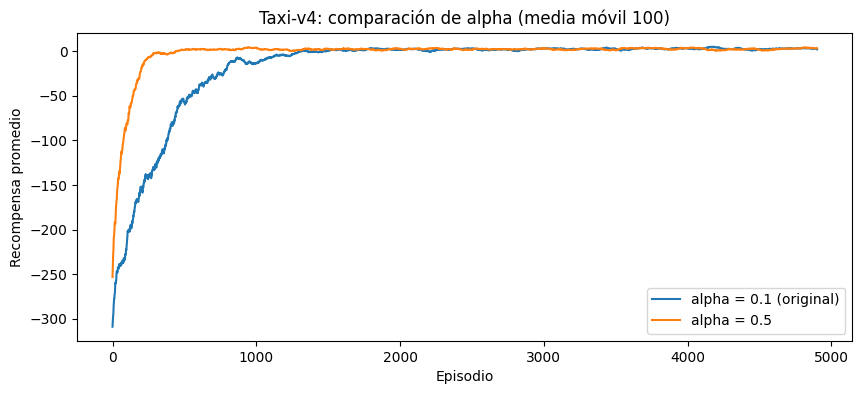

alpha=0.1: media móvil >= 0 desde episodio 1403, desv. últimos 1000 = 7.89, media últimos 1000 = 2.75, greedy: recompensa 8.04, pasos 13.0, éxito 100%
alpha=0.5: media móvil >= 0 desde episodio 546, desv. últimos 1000 = 7.58, media últimos 1000 = 2.50, greedy: recompensa 7.88, pasos 13.1, éxito 100%


In [17]:
random.seed(SEED); np.random.seed(SEED)
env.reset(seed=SEED); env.action_space.seed(SEED)

Q_alpha, rewards_alpha = train_q_learning(
    env,
    np.zeros((n_states, n_actions)),
    episodes=5000,
    alpha=0.5,      # único cambio
    gamma=0.95,
    epsilon=0.1
)

ma_alpha = np.convolve(rewards_alpha, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(moving_average, label="alpha = 0.1 (original)")
plt.plot(ma_alpha, label="alpha = 0.5")
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Taxi-v4: comparación de alpha (media móvil {window})")
plt.legend()
plt.show()

def first_episode_above(ma, threshold=0):
    idx = np.flatnonzero(ma >= threshold)
    return int(idx[0]) + window if len(idx) else None

for name, r, ma, Qx in [("alpha=0.1", rewards, moving_average, Q_trained),
                        ("alpha=0.5", rewards_alpha, ma_alpha, Q_alpha)]:
    m, s, ok = evaluate_policy(env, Qx)
    print(f"{name}: media móvil >= 0 desde episodio {first_episode_above(ma)}, "
          f"desv. últimos 1000 = {np.std(r[-1000:]):.2f}, "
          f"media últimos 1000 = {np.mean(r[-1000:]):.2f}, "
          f"greedy: recompensa {m:.2f}, pasos {s:.1f}, éxito {ok:.0%}")

In [18]:
frames_alpha, reward_alpha = play_episode(env, Q_alpha, max_steps=200, seed=7)
print("Recompensa total con alpha = 0.5:", reward_alpha)
frames_to_video(frames_alpha, interval=500)

Recompensa total con alpha = 0.5: 10


### Pregunta 7

**Respuesta:**

Cambié únicamente $\alpha$, de 0.1 a 0.5.

1. **Velocidad de aprendizaje:** mejoró mucho. Con $\alpha=0.5$ la media móvil cruza cero alrededor del episodio 550, contra el episodio 1400 con $\alpha=0.1$. Un $\alpha$ mayor hace que cada experiencia mueva más el valor Q hacia el target TD, así que la información del $+20$ final se propaga más rápido hacia los estados anteriores. Taxi es determinístico, entonces el target de una misma transición siempre es igual y no hay mucho ruido que promediar, por eso un paso grande funciona bien.
2. **Estabilidad:** una vez estabilizadas, las dos curvas son prácticamente iguales; la desviación de la recompensa en los últimos 1000 episodios fue 7.9 con $\alpha=0.1$ y 7.6 con $\alpha=0.5$. Esa variabilidad viene sobre todo de la exploración y del punto de partida aleatorio, no del tamaño del paso. En un ambiente estocástico esperaríamos que un $\alpha$ alto hiciera los valores más oscilantes.
3. **Recompensa final:** casi idéntica. Media de los últimos 1000 episodios de 2.75 frente a 2.50, y en evaluación greedy 8.04 frente a 7.88, ambas con 100 % de éxito y unos 13 pasos. La diferencia es ruido; las dos llegaron a una política prácticamente óptima.
4. **Comportamiento observado:** en el episodio con `seed=7` los dos agentes hacen la misma ruta y obtienen $+10$. El cambio de $\alpha$ afecta cuánto tarda el agente en aprender, no a qué política llega.

## Entrega

El notebook debe contener:

1. implementación de `choose_action`;
2. implementación de `update_q`;
3. implementación de `train_q_learning`;
4. curva de aprendizaje;
5. visualización del agente antes y después del entrenamiento;
6. respuestas a las siete preguntas.

No es necesario modificar las funciones auxiliares de visualización.
